## Lab 5: Non-linear Binary Classification using Neural Networks 

In [28]:
import torch
print(torch.__version__)

2.13.0+cpu


In [29]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f'Using device ={device}')

Using device =cpu


Shape of X and y = (1000, 2), (1000,)


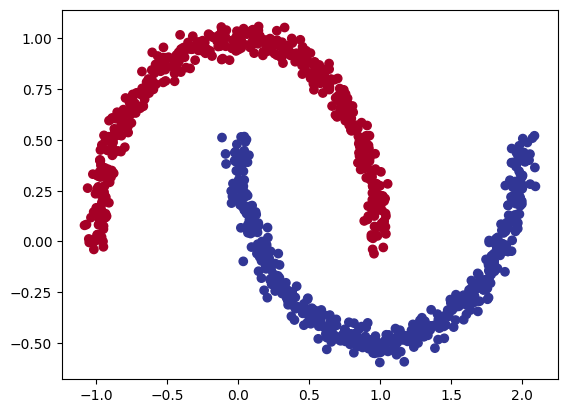

In [30]:
# Generate the Dataset
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=1000, noise=0.04, random_state=42)

print(f"Shape of X and y = {X.shape}, {y.shape}")
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [31]:
# Train-test Split
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# Define the model class
from torch import nn
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [33]:
# Instantiate the model and inspect parameters
model = NeuralNetwork()
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [34]:
# Define loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.05)

In [35]:
# define an accuracy function
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_true))*100
    return acc

In [36]:
# Training Loop
epochs = 2500
train_loss_list = []
test_loss_list = []
torch.manual_seed(42)
# Cast the model and data to the device
model.to(device)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### TRAINING
    model.train()

    # Forward Pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Compute Loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # Optimizer Zero Grad
    optimizer.zero_grad()

    # Backpropagate
    loss.backward()

    # Step the optimizer
    optimizer.step()

    ### TESTING
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)
    train_loss_list.append(loss.item())
    test_loss_list.append(test_loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}|Loss {loss:.5f}|Acc {acc:.2f}|Test Loss {test_loss:.5f}|Test Acc {test_acc:.2f}')

Epoch 100|Loss 0.59430|Acc 75.25|Test Loss 0.60216|Test Acc 70.50
Epoch 200|Loss 0.38720|Acc 81.75|Test Loss 0.40395|Test Acc 76.50
Epoch 300|Loss 0.28871|Acc 86.25|Test Loss 0.29764|Test Acc 84.50
Epoch 400|Loss 0.23777|Acc 88.50|Test Loss 0.23837|Test Acc 90.00
Epoch 500|Loss 0.21082|Acc 90.12|Test Loss 0.20634|Test Acc 92.00
Epoch 600|Loss 0.19260|Acc 91.00|Test Loss 0.18616|Test Acc 92.50
Epoch 700|Loss 0.17435|Acc 92.38|Test Loss 0.16696|Test Acc 93.50
Epoch 800|Loss 0.15397|Acc 93.62|Test Loss 0.14596|Test Acc 93.50
Epoch 900|Loss 0.13196|Acc 94.75|Test Loss 0.12360|Test Acc 95.50
Epoch 1000|Loss 0.10997|Acc 95.50|Test Loss 0.10164|Test Acc 97.00
Epoch 1100|Loss 0.08949|Acc 96.88|Test Loss 0.08185|Test Acc 98.50
Epoch 1200|Loss 0.07189|Acc 98.25|Test Loss 0.06483|Test Acc 99.00
Epoch 1300|Loss 0.05754|Acc 99.00|Test Loss 0.05133|Test Acc 99.50
Epoch 1400|Loss 0.04646|Acc 99.25|Test Loss 0.04101|Test Acc 99.50
Epoch 1500|Loss 0.03813|Acc 99.62|Test Loss 0.03323|Test Acc 100.00
Epo

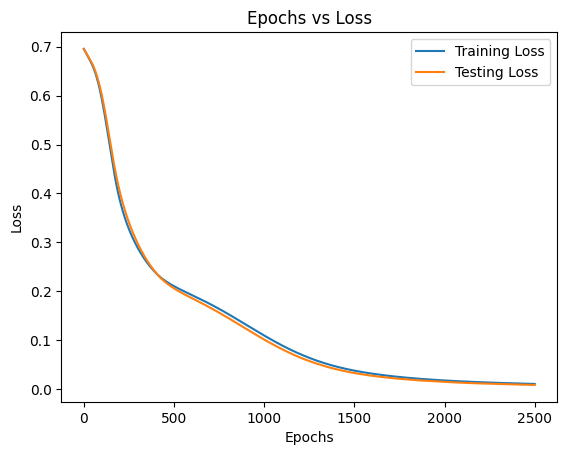

In [ ]:
# Plot loss curve
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Epochs vs Loss");

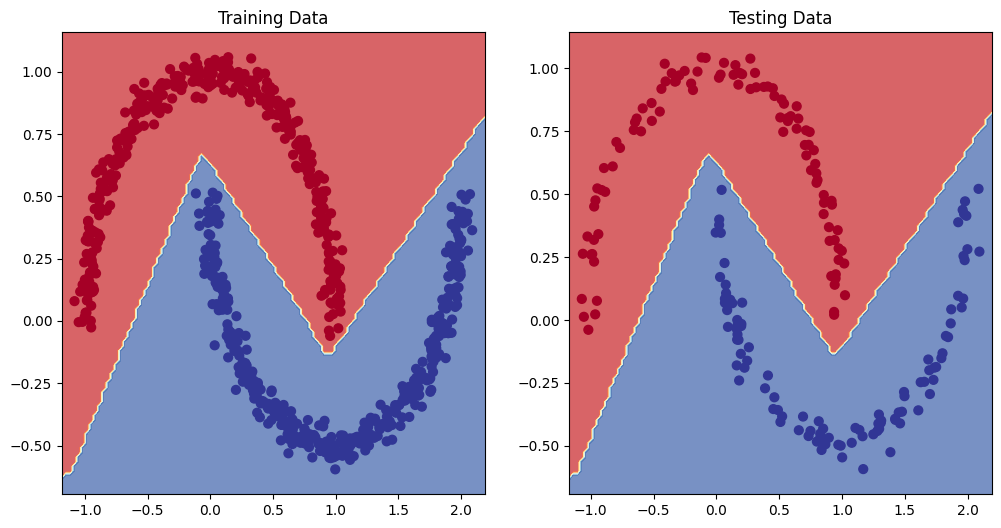

In [38]:
# Visualize the decision boundry
from helper_functions import plot_decision_boundary

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)